# Ensemble Learning Using AdaBoost
## Project
Pima Indians Diabetes Dataset Classification Models

## Objective
The objective of this notebook is to implement an AdaBoost classifier, evaluate its performance on the Pima Indians Diabetes Dataset, and compare its results with the previous classification models.

AdaBoost is an ensemble learning technique that combines multiple weak learners sequentially, with each new learner focusing on correcting the mistakes made by the previous ones.

## Dataset
**Dataset:** Pima Indians Diabetes Dataset

The dataset contains medical diagnostic measurements collected from female patients of Pima Indian heritage. The goal is to predict whether a patient has diabetes based on several health-related features.

### Features
- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

### Target Variable
- Outcome
  - 0 = Non-diabetic
  - 1 = Diabetic

## Workflow
1. Import required libraries.
2. Load the dataset.
3. Split the data into features and target.
4. Split the dataset into training and testing sets.
5. Train the AdaBoost classifier.
6. Make predictions.
7. Evaluate the model using accuracy, confusion matrix, classification report and ROC-AUC.
8. Compare AdaBoost with previous models.
9. Draw conclusions.

## Key Concepts
- Ensemble Learning
- Boosting
- Weak Learners
- Decision Stumps
- Sequential Model Training
- Model Evaluation

# LIBRARIES

In [13]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt


## Why Is Feature Scaling Not Required Here?

AdaBoost is using Decision Stumps as its base learners. Decision Stumps are tree-based models, and tree-based models are generally not sensitive to feature scaling.

Because of this, the AdaBoost model can be trained directly on the original feature values without applying StandardScaler.

# LOAD DATASET

In [6]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# FEATURES AND TARGET

In [9]:
# Featues
X = df.drop("Outcome", axis=1)
# Target
y = df["Outcome"]


# TRAIN TEST DATA SPLIT

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# TRAINING THE ADABOOST MODEL

In [15]:
# Creating the Stump
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
# Creaing the Ada Boost model
ada_boost = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada_boost.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.27,0.36,0.36,...,0.47,0.47,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.02,0.57,0.58,...,0.12,0.11,0.08]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](8,)","[0. ,0.31,0.03,...,0.24,0.17,0.24]"


# MAKING PREDICTION

In [16]:
# Y_pred gives the final prediction of each patient
y_pred = ada_boost.predict(X_test)
# Y_prob gives the probability of a patient being in class 1(Diabetic)
y_prob = ada_boost.predict_proba(X_test)[:, 1]


# EVALUATING THE MODELS PERFORMANCE

In [17]:
# Accuracy
ada_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {ada_accuracy:.2f}")

Accuracy: 0.78


In [21]:
# Classification Report
cr = classification_report(y_test, y_pred)
print(f"Classification Report: {cr}")

Classification Report:               precision    recall  f1-score   support

           0       0.84      0.81      0.82        99
           1       0.68      0.73      0.70        55

    accuracy                           0.78       154
   macro avg       0.76      0.77      0.76       154
weighted avg       0.78      0.78      0.78       154



Ada Confusion Matrix: [[80 19]
 [15 40]]


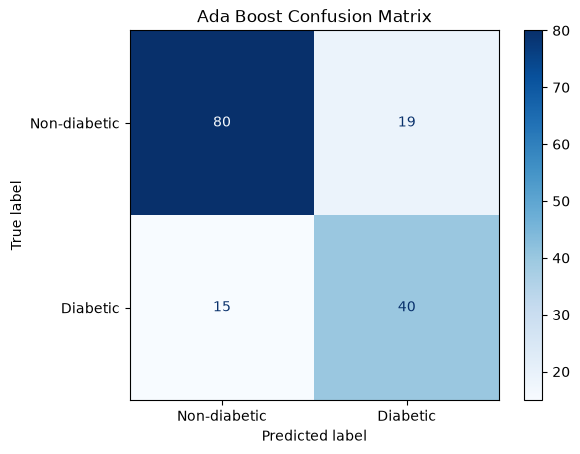

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"Ada Confusion Matrix: {cm}")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
)
disp.plot(cmap="Blues")
plt.title("Ada Boost Confusion Matrix")
plt.show()

ROC-AUC Score: 0.81


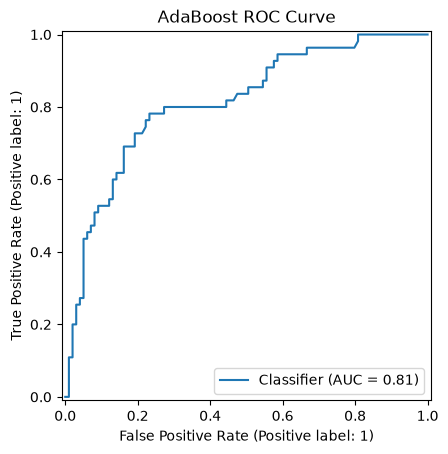

In [22]:
# ROC_AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(roc_auc, 2))
# ROC_AUC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("AdaBoost ROC Curve")
plt.show()

## AdaBoost Results

The AdaBoost classifier achieved an accuracy of **78%** on the Pima Indians Diabetes Dataset, making it slightly better than the Voting Classifier models tested earlier.

It correctly classified 80 non-diabetic patients and 40 diabetic patients, with a confusion matrix of [[80, 19], [15, 40]].

AdaBoost also produced a ROC-AUC score of **0.81**, showing strong ability to distinguish between the two classes. Its recall for the diabetic class was particularly good, indicating that it identified more diabetic patients than the previous ensemble methods.

Overall, AdaBoost performed very well on this dataset and showed that boosting can improve classification performance by combining weak learners sequentially.

# ADABOOST VS VOTING
## Final Comparison of Ensemble Models

This notebook compared two ensemble learning techniques on the Pima Indians Diabetes Dataset: Voting Classifier and AdaBoost.

The Voting Classifier combined the predictions of Logistic Regression, K-Nearest Neighbours (K = 18) and Support Vector Machine using both Hard Voting and Soft Voting. Both voting methods achieved an accuracy of **77%**. Hard Voting produced slightly better recall for the diabetic class, while Soft Voting produced slightly better precision and an ROC-AUC score of **0.81**.

AdaBoost performed slightly better overall, achieving an accuracy of **78%**, a recall of **0.73** for the diabetic class and an ROC-AUC score of **0.81**. This suggests that boosting was more effective than simple voting on this dataset.

Overall, the results show that ensemble learning can improve classification performance, but different ensemble methods may perform better depending on the dataset and evaluation metric.

# CONCLUSION

In this notebook, ensemble learning was applied to the Pima Indians Diabetes Dataset using Voting Classifier and AdaBoost.

The Voting Classifier combined Logistic Regression, K-Nearest Neighbours and Support Vector Machine, while AdaBoost used decision stumps as weak learners trained sequentially. Both approaches produced strong results, with accuracies between **77% and 78%**.

Hard Voting and Soft Voting each achieved an accuracy of **77%**, while AdaBoost achieved the best overall performance with an accuracy of **78%** and stronger recall for the diabetic class. This is important because correctly identifying diabetic patients is a key goal in medical classification problems.

The experiment also showed that different ensemble methods can behave differently even when they achieve similar accuracy. For that reason, it is important to evaluate models using more than one metric and to choose the method that best fits the problem.

This notebook completes the ensemble learning section of the project and provides a clear comparison of voting-based and boosting-based approaches on the same healthcare dataset.